# Рабочая тетрадь по ПСИИ №5

## Студента группы БФБО-06-24 Петрова Артема

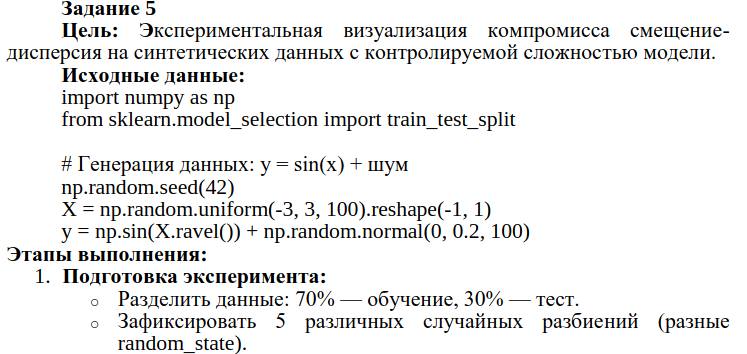

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

# Генерация данных: y = sin(x) + шум
X = np.random.uniform(-3, 3, 100).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.2, 100)

# Разбиение данных (5 случайных разбиений):
rand_states = [42, 123, 456, 789, 999]
splits = []
for i in rand_states:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = i)
    splits.append((X_train, X_test, y_train, y_test))

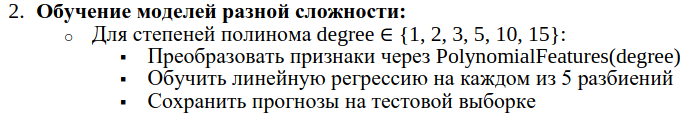

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Для удобства был сделан список со степенями полинома:
degrees = [1, 2, 3, 5, 10, 15]

# Так же, был создан словарь для хранения предсказаний
predictions = {degree: [] for degree in degrees}

# Далее через цикл были преобразованы признаки, создана и обучена модель и сделаны предсказания:
# Цикл для перебора степеней полинома
for deg in degrees:
    # Цикл для перебора данных:
    for i, (X_train, X_test, y_train, y_test) in enumerate(splits):
        # Выбор степени
        poly = PolynomialFeatures(degree = deg, include_bias = False)
        # Преобразование данных для обучения
        X_train_poly = poly.fit_transform(X_train)
        # Создание и обучение модели
        model = LinearRegression().fit(X_train_poly, y_train)
        # Преобразование тестовых данных
        X_test_poly = poly.transform(X_test)
        # Создание предсказаний и последующее добавление их в словарь
        y_pred = model.predict(X_test_poly)
        predictions[deg].append(y_pred)

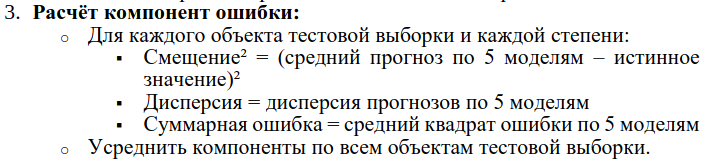

In [62]:

# Так как все выборки одинакового размера, возьмём данные из первой
X_test_common = splits[0][1]
y_test_common = splits[0][3]

# Списки для хранения результатов
bias2_list = []
variance_list = []
sum_error_list = []

for deg in degrees:
    # Получение всех предсказаний для данной степени
    pred_deg = np.array(predictions[deg])
    
    # Создание списков для хранения значений
    bias2_sample = []
    variance_sample = []
    mse_sample = []

    for i in range(len(y_test_common)):
        # предсказание 5 моделей для объекта i
        pred_i = pred_deg[:, i]
        # расчёт смещения^2
        mean_pred = np.mean(pred_i)
        bias2 = (mean_pred - y_test_common[i]) ** 2
        # расчёт дисперсии прогнозов
        variance = np.var(pred_i, ddof=1) #
        # Расчёт среднеквадратической ошибки для объекта i
        mse = np.mean((pred_i - y_test_common[i]) ** 2)
        
        bias2_sample.append(bias2)
        variance_sample.append(variance)
        mse_sample.append(mse)

    # Усреднение по всем объектам
    bias2_list.append(np.mean(bias2_sample))
    variance_list.append(np.mean(variance_sample))
    sum_error_list.append(np.mean(mse_sample))

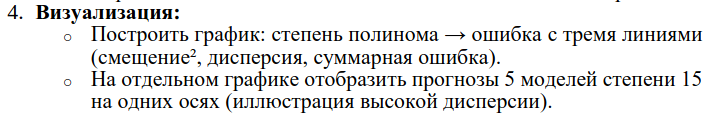

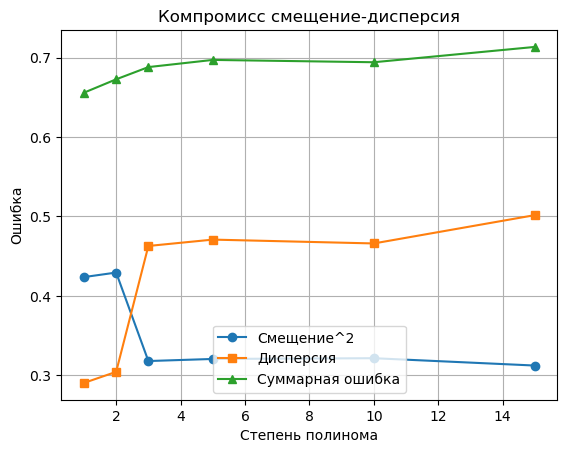

In [63]:
import matplotlib.pyplot as plt

plt.plot(degrees, bias2_list, 'o-', label = 'Смещение^2')
plt.plot(degrees, variance_list, 's-', label = 'Дисперсия')
plt.plot(degrees, sum_error_list, '^-', label = 'Суммарная ошибка')
plt.xlabel('Степень полинома')
plt.ylabel('Ошибка')
plt.title('Компромисс смещение-дисперсия')
plt.legend()
plt.grid()
plt.show()

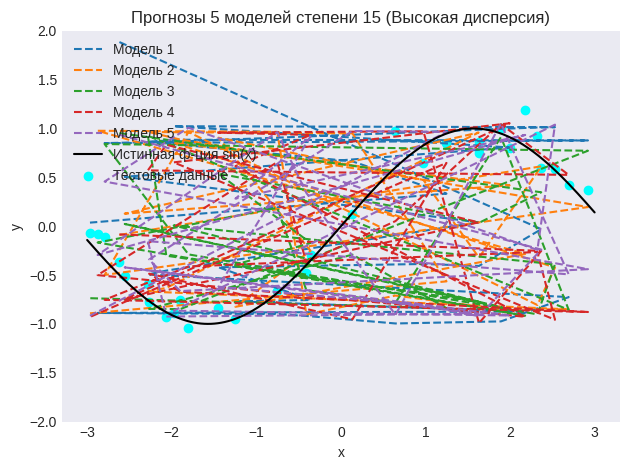

In [88]:
# Чтобы сделать линии красивее, тестовые данные были отсортированы
X_test_sorted = np.sort(X_test_common)
X_test_flat = X_test_sorted.ravel()

for i in range(5):
    #
    pred_i = predictions[15][i]
    #
    sort_idx = np.argsort(X_test_common.ravel())
    pred_i_sorted = pred_i[sort_idx]
    
    plt.plot(X_test_flat, pred_i_sorted, '--', label = f'Модель {i + 1}')
    
X_true = np.linspace(-3, 3, 300)
y_true = np.sin(X_true)
plt.plot(X_true, y_true, 'k-', label = 'Истинная ф-ция sin(x)')

plt.scatter(X_test_common, y_test_common, color = 'cyan', label = 'Тестовые данные')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Прогнозы 5 моделей степени 15 (Высокая дисперсия)')
plt.legend(loc = 'upper left')
plt.grid()
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

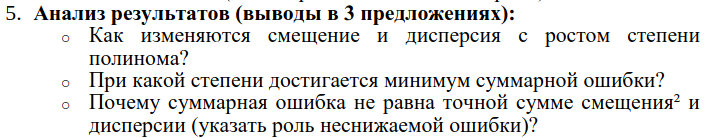

## Как изменяются смещение и дисперсия с ростом степени полинома? 

Чем выше степень полинома - тем выше дисперсия и тем ниже смещение. При высокой дисперсии модель пытается подогнаться под каждую точку, включая шум, при этом, если данные чуть меняются, то и модель меняется кардинально, что говорит о переобучении модели. При высоком смещении же наоборот, модель не имеет гибкости или имеет низкую гибкость.

## При какой степени достигается минимум суммарной ошибки?

В нашем, предположительно из-за данных, значение MSE очень велико и модели получились плохими. Но теоретически, минимальное значение MSE должно достигаться на 3-й или 5-й степени полинома

## Почему суммарная ошибка не равна точной сумме смещения^2 и дисперсии (указать роль неснижаемой ошибки)?

Потому что суммарная ошибка (MSE) раскладывается как:

MSE = Смещение^2 + Дисперсия + **Неснижаемая ошибка**.

Неснижаемая ошибка - это дисперсия шума в данных в нашем случае (np.random.normal(0, 0.2, 100)). Поэтому значение суммарной ошибки будет всегда немного больше суммы смещения в квадрате и дисперсии.